In [51]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
f_sig = "../coffea/AllInOne_2022/Resolution.coffea"

sig_histo = util.load(f_sig) [0]

[ 0.          0.          0.          1.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  1.41421356  1.          0.          1.41421356  1.          0.
  0.          1.41421356  1.          1.          1.73205081  1.41421356
  2.          2.23606798  1.          2.          1.          2.64575131
  2.64575131  3.46410162  2.44948974  4.12310563  3.46410162  4.89897949
  5.47722558  6.08276253  6.32455532  6.92820323  8.66025404  9.79795897
 10.95445115 15.13274595 15.3622915  11.04536102  9.05538514  6.78232998
  6.63324958  5.65685425  5.09901951  4.58257569  3.16227766  2.82842712
  2.          1.73205081  2.          0.          1.73205081  2.
  0.          0.          1.          0.          1.          0.
  0.          0.          1.          0.          0.          0.
  0.          1.          0.          0.          0.          0.
  0.          0.          0.          0.  

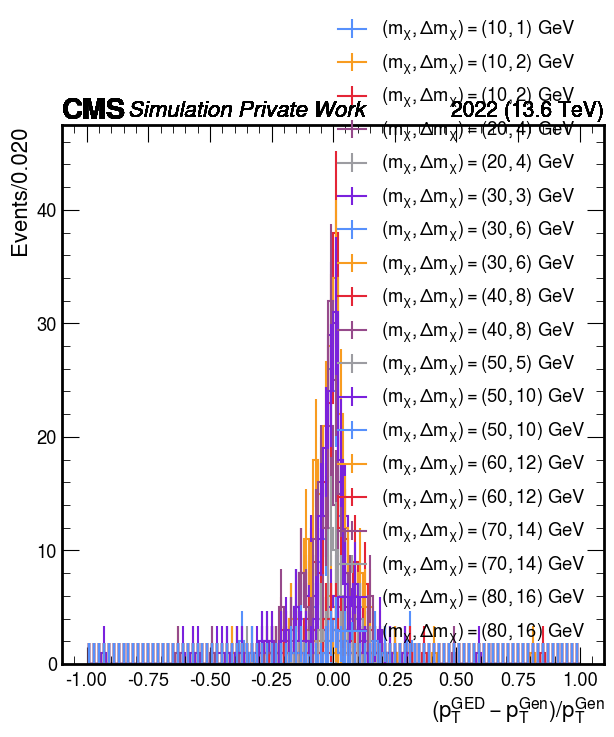

In [53]:
fig, ax = plt.subplots(figsize=(7,7))



# Plot settings
plot_dict = {
    'variable':'res_GED_gen',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points

samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
          0.2: [1,100],
    }
 
}

results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    for m1, deltas in samples.items()
    for delta, ctaus in deltas.items()
    for ctau in ctaus
]

counts, edges, yerror = zip(*results)

yerror = np.array(yerror)

edge = edges[0]
bins_x = (edge[:-1] + edge[1:])*(0.5)

summed = np.sum(counts, axis=0) #summing the counts per bin

YERROR = (np.sqrt (np.sum( ( (yerror)**2), axis=0 )))
print (YERROR)

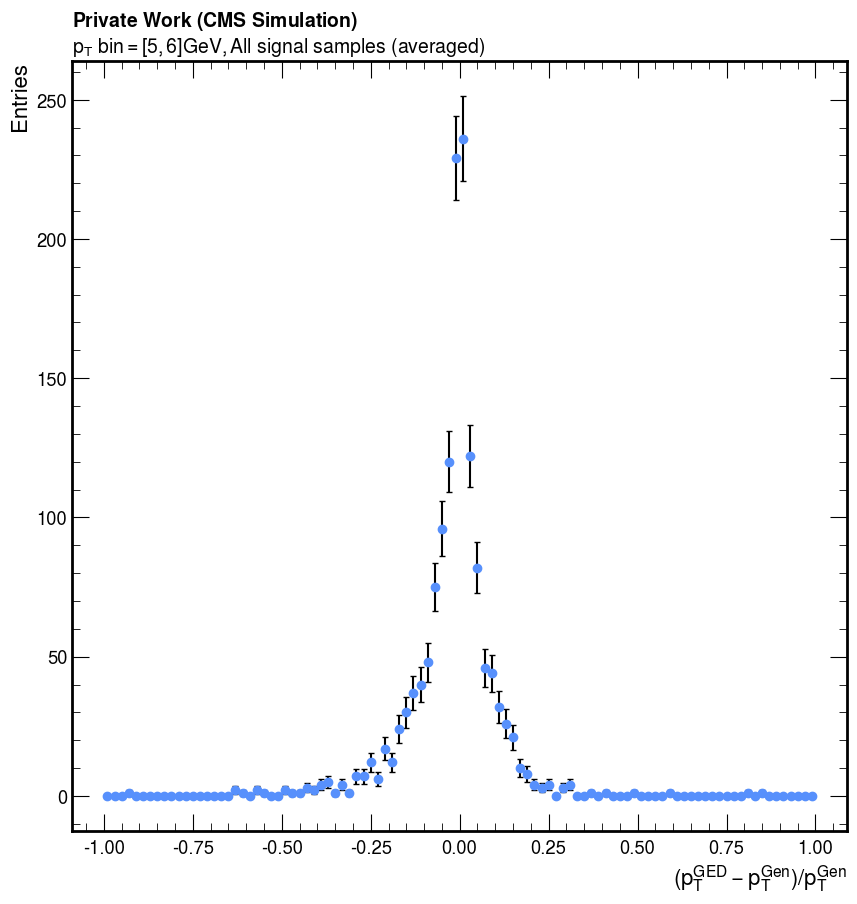

In [54]:
plt.errorbar(bins_x, summed, yerr=YERROR, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6] GeV, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)

plt.show()

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          1.          1.          0.          1.
  1.          0.          1.41421356  0.          2.23606798  0.
  2.64575131  1.41421356  1.          2.          2.44948974  2.
  2.23606798  3.16227766  3.          2.          4.          4.35889894
  4.24264069  6.164414    5.29150262  6.70820393  7.74596669  8.71779789
 10.95445115 14.31782106 14.59451952  9.32737905  6.4807407   6.164414
  5.29150262  4.35889894  5.          3.          2.44948974  3.16227766
  2.64575131  1.73205081  1.          1.          1.          1.
  1.          0.          0.          0.          0.          0.
  1.41421356  0.          0.          1.          0.          0.
  1.          1.          0.          0.          0.          1.
  0.          1.          0.          0.          0.        

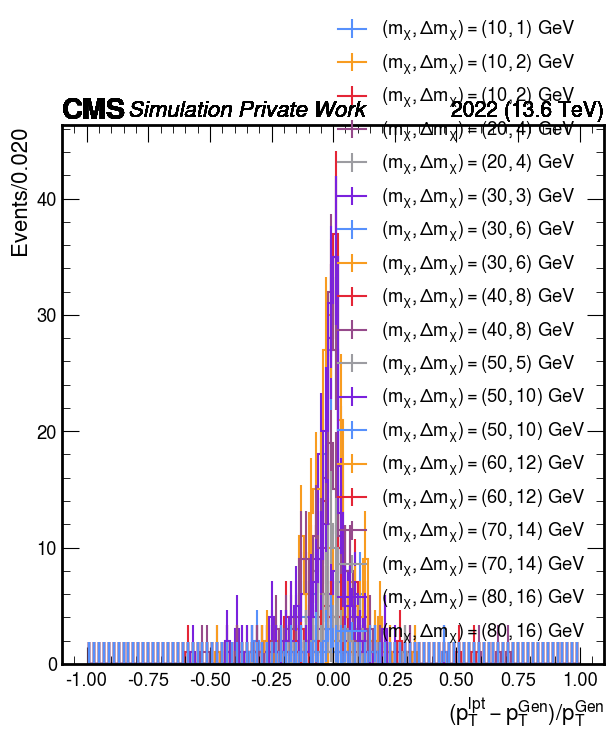

In [55]:
fig, ax = plt.subplots(figsize=(7,7))



# Plot settings
plot_dict = {
    'variable':'res_LPT_gen',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points

samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
          0.2: [1,100],
    }
 
}

results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    for m1, deltas in samples.items()
    for delta, ctaus in deltas.items()
    for ctau in ctaus
]


counts_lpt, edges_lpt, yerror_lpt = zip(*results_lpt)

yerror_lpt = np.array(yerror_lpt)

edge_lpt = edges_lpt[0]
bins_x_lpt = (edge_lpt[:-1] + edge_lpt[1:])*(0.5)

sum_lpt = np.sum(counts_lpt, axis=0)

YERROR_lpt = (np.sqrt (np.sum( ( (yerror_lpt)**2), axis=0 )))
print (YERROR_lpt)



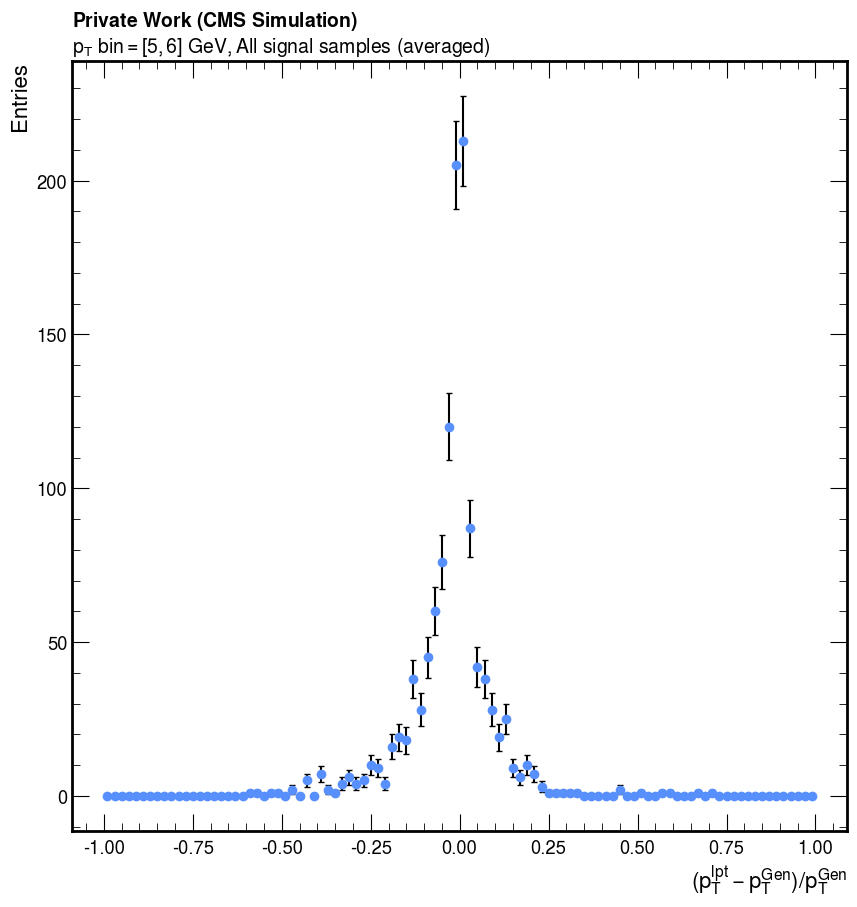

In [56]:
plt.errorbar(bins_x_lpt, sum_lpt, yerr=YERROR_lpt, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")
plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6]\ GeV, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)
plt.show()